# Project Preprocessing: Expert Discovery System and Collaboration Network Analysis with HORUS data

# 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from spellchecker import SpellChecker
from tqdm import tqdm

import os
from pathlib import Path

# NLP - Classical pipeline
import ftfy
from gensim.models.phrases import Phrases, Phraser
import nltk
from nltk.corpus import stopwords

# Language detection
from lingua import Language, LanguageDetectorBuilder

# spaCy (multilingual lemmatization)
import spacy

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Downloads
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All imports successful.")

[nltk_data] Downloading package punkt to
[nltk_data]     /home/fvalderramab/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/fvalderramab/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/fvalderramab/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/fvalderramab/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/fvalderramab/nltk_data...


All imports successful.


[nltk_data]   Package omw-1.4 is already up-to-date!


### 1.1. Environment Configuration (Mounting Drive)

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    base_path = Path("/content/drive/Shareddrives/Minería/proyecto_horus/data/")
else:
    base_path = Path("../data/")

### 1.2. Faculty-Level Data Loading

Load faculty-specific datasets and assign the Facultad label explicitly.

In [3]:
productos_ingenieria = pd.read_excel(base_path / "raw/productos_ingenieria.xlsx").assign(Facultad='Ingeniería')
productos_artes = pd.read_excel(base_path / "raw/productos_artes.xlsx").assign(Facultad='Artes')
productos_ciencias_agrarias = pd.read_excel(base_path / "raw/productos_ciencias_agrarias.xlsx").assign(Facultad='Ciencias Agrarias')
productos_ciencias_economicas = pd.read_excel(base_path / "raw/productos_ciencias_economicas.xlsx").assign(Facultad='Ciencias Económicas')
productos_ciencias_humanas = pd.read_excel(base_path / "raw/productos_ciencias_humanas.xlsx").assign(Facultad='Ciencias Humanas')
productos_ciencias = pd.read_excel(base_path / "raw/productos_ciencias.xlsx").assign(Facultad='Ciencias')
productos_derecho = pd.read_excel(base_path / "raw/productos_derecho.xlsx").assign(Facultad='Derecho')
productos_enfermeria = pd.read_excel(base_path / "raw/productos_enfermeria.xlsx").assign(Facultad='Enfermería')
productos_medicina = pd.read_excel(base_path / "raw/productos_medicina.xlsx").assign(Facultad='Medicina')
productos_odontologia = pd.read_excel(base_path / "raw/productos_odontologia.xlsx").assign(Facultad='Odontología')
productos_veterinaria = pd.read_excel(base_path / "raw/productos_veterinaria.xlsx").assign(Facultad='Veterinaria')

productos_bogota = pd.concat([
    productos_ingenieria,
    productos_artes,
    productos_ciencias_agrarias,
    productos_ciencias_economicas,
    productos_ciencias_humanas,
    productos_ciencias,
    productos_derecho,
    productos_enfermeria,
    productos_medicina,
    productos_odontologia,
    productos_veterinaria
], ignore_index=True)

docentes_investigadores = pd.read_csv(base_path / 'external/docentes_investigadores.csv')
docentes_investigadores_activos = docentes_investigadores[docentes_investigadores['Vinculación'] == 'Activo'].reset_index(drop=True)

### 1.3. Useful functions

In [4]:
CONVENCIONES_NULAS_ESTATICAS = {
    # Generic nulos
    'no reportado', 'no disponible', 'sin información', 'sin informacion',
    'n/a', 'na', 'none', 'nd', 'n.d.', 'n.a.', 's.r.', 'nr', 'nan',
    # Punctuation-only
    '-', '--', '---', '----------', '.', '..', '...', '_', '__',
    # Single characters / trivial
    'a', 'x', 'xx', 'xxx', 'xxxx', '1', '0',
    # Spanish document references (useless for NLP)
    'ver documento completo en pdf',
    'ver documento completo',
    'ver pdf',
    'documento adjunto',
    'véase documento',
    'desconocido',
    # Empty string
    '',
}

# Regex-based check for additional patterns (repeated chars, only symbols)
CONVENCION_PATTERNS = [
    r'^\s*[-_=*#.]{2,}\s*$',      # e.g. '-----', '======'
    r'^\s*[a-zA-Z0-9]\s*$',       # single character
    r'^\s*\d{1,2}\s*$',           # 1 or 2 digit numbers
    r'^ver\s+documento',           # "ver documento completo en PDF" variants
    r'^n\.?\s*[ad]\.?\s*$',        # N.A., N.D., etc.
    r'^s\.?\s*r\.?\s*$',           # S.R.
    r'^\W+$',                      # only non-word characters
]

def normalizar_para_match(nombre):
    nombre = str(nombre).lower().strip()
    nombre = ''.join(c for c in unicodedata.normalize('NFD', nombre)
                     if unicodedata.category(c) != 'Mn')
    nombre = re.sub(r'[.,]', '', nombre)
    return ' '.join(nombre.split())

def extraer_coautores(texto):
    if pd.isna(texto):
        return []
    return [nombre.strip() for nombre in str(texto).split(',') if nombre.strip()]

def tiene_docente_activo(coautores_str, docentes_set):
    nombres = extraer_coautores(coautores_str)
    return any(normalizar_para_match(n) in docentes_set for n in nombres)

### 1.4. Filter to active professors only

In [5]:
docentes_activos_nombres = set(
    docentes_investigadores_activos['Nombre'].dropna().apply(normalizar_para_match)
)
mascara_activos = productos_bogota['Coautores'].apply(
    lambda x: tiene_docente_activo(x, docentes_activos_nombres)
)
productos_bogota = productos_bogota[mascara_activos].copy().reset_index(drop=True)
print(f"Records with at least one active professor: {len(productos_bogota)}")
print(f"Records excluded: {len(mascara_activos) - mascara_activos.sum()}")

Records with at least one active professor: 109836
Records excluded: 43488


# 2. Preprocessing phase

## 2.1. Shared Preprocessing (Preprocessing for embeddings)

### 2.1.1. Basic Text Normalization & Noise Removal

#### 2.1.1.1. Corrupt character repair (Mojibake)

Fixes bytes decoded with the wrong codec (e.g. UTF-8 read as latin-1).
Must run first because it operates on raw byte-level corruption patterns.
Different from Unicode normalization in 2.1.1.3, which handles valid but
inconsistent Unicode characters (curly quotes, special dashes, etc.).

In [6]:
print("=" * 60)
print("CORRUPT CHARACTER REPAIR")
print("=" * 60)

# Common mojibake patterns in Spanish academic texts
MOJIBAKE_MAP = {
    'Ã¡': 'á', 'Ã©': 'é', 'Ã­': 'í', 'Ã³': 'ó', 'Ãº': 'ú',
    'Ã ': 'à', 'Ã¨': 'è', 'Ã¬': 'ì', 'Ã²': 'ò', 'Ã¹': 'ù',
    'Ã\x81': 'Á', 'Ã\x89': 'É', 'Ã\x8d': 'Í', 'Ã\x93': 'Ó', 'Ã\x9a': 'Ú',
    'Ã±': 'ñ', 'Ã\x91': 'Ñ',
    'Ã¼': 'ü', 'Ã\x9c': 'Ü',
    'â€œ': '"', 'â€': '"', 'â€™': "'", 'â€˜': "'",
    'â€"': '–', 'â€"': '—',
    'Â°': '°', 'Â©': '©', 'Â®': '®',
    '\x00': '',   # null bytes
    # '\ufffd': '', # replacement character �
}

def reparar_mojibake(texto):
    """Attempt to fix common encoding corruption patterns."""
    if pd.isna(texto):
        return texto
    texto = str(texto)
    for corrupto, correcto in MOJIBAKE_MAP.items():
        texto = texto.replace(corrupto, correcto)
    # Try ftfy as a fallback if available
    try:
        texto = ftfy.fix_text(texto)
    except ImportError:
        pass
    return texto


# --- Capture before state for comparison ---
titulo_antes   = productos_bogota['Título original'].copy()
desc_antes     = productos_bogota['Descripción original'].copy()

# --- Apply repair ---
for col in ['Título original', 'Descripción original']:
    productos_bogota[col] = productos_bogota[col].apply(reparar_mojibake)

# --- Identify changed rows ---
titulo_cambio = titulo_antes.fillna('') != productos_bogota['Título original'].fillna('')
desc_cambio   = desc_antes.fillna('')   != productos_bogota['Descripción original'].fillna('')
cualquier_cambio = titulo_cambio | desc_cambio

print(f"Titles repaired:       {titulo_cambio.sum()}")
print(f"Descriptions repaired: {desc_cambio.sum()}")
print(f"Any field repaired:    {cualquier_cambio.sum()}")

if cualquier_cambio.sum() > 0:
    comparacion = []
    for idx in productos_bogota[cualquier_cambio].index:
        comparacion.append({
            'Título ANTES':        str(titulo_antes.at[idx]),
            'Título DESPUÉS':      str(productos_bogota.at[idx, 'Título original']),
            'Título cambió':       titulo_cambio[idx],
            'Desc ANTES (120c)':   str(desc_antes.at[idx])[:500],
            'Desc DESPUÉS (120c)': str(productos_bogota.at[idx, 'Descripción original'])[:500],
            'Desc cambió':         desc_cambio[idx],
        })
    df_comparacion = pd.DataFrame(comparacion)
    display(df_comparacion[df_comparacion[['Título cambió', 'Desc cambió']].any(axis=1)].head(50))
else:
    print("\nNo mojibake detected. Checking high-density non-ASCII characters:")
    unicode_density = productos_bogota['Título original'].fillna('').apply(
        lambda t: sum(1 for c in t if ord(c) > 127) / max(len(t), 1)
    )
    sospechosos = unicode_density[unicode_density > 0.15].index
    print(f"High-unicode-density titles found: {len(sospechosos)}")
    if len(sospechosos):
        display(productos_bogota.loc[sospechosos,
                ['Título original', 'Descripción original', 'Facultad']].head(10))

del titulo_antes, desc_antes, titulo_cambio, desc_cambio, cualquier_cambio

CORRUPT CHARACTER REPAIR
Titles repaired:       1109
Descriptions repaired: 6366
Any field repaired:    6996


,Título ANTES,Título DESPUÉS,Título cambió,Desc ANTES (120c),Desc DESPUÉS (120c),Desc cambió
0,Recent advances in solvent development for car...,Recent advances in solvent development for car...,False,"The practices of carbon capture, storage, and ...","The practices of carbon capture, storage, and ...",True
1,Computational Model of Bone Remodeling Integra...,Computational Model of Bone Remodeling Integra...,False,Bone remodeling is a fundamental physiological...,Bone remodeling is a fundamental physiological...,True
2,Kernel density matrices for probabilistic deep...,Kernel density matrices for probabilistic deep...,False,This paper introduces a novel approach to prob...,This paper introduces a novel approach to prob...,True
3,"Functional Data Analysis for the Structural, C...","Functional Data Analysis for the Structural, C...",False,Additive manufacturing via selective laser sin...,Additive manufacturing via selective laser sin...,True
4,Mechanical Behavior of Paving Stones Made from...,Mechanical Behavior of Paving Stones Made from...,False,This study investigates the mechanical perform...,This study investigates the mechanical perform...,True
5,Corrosion Performance of (TiAlZrTaNb)Nx High-E...,Corrosion Performance of (TiAlZrTaNb)Nx High-E...,False,"In this study, the electrochemical corrosion b...","In this study, the electrochemical corrosion b...",True
6,Inteligencia artificial en la educación en ing...,Inteligencia artificial en la educación en ing...,False,La irrupción de la inteligencia artificial (IA...,La irrupción de la inteligencia artificial (IA...,True
7,M-Learning: Heuristic Approach for Delayed Rew...,M-Learning: Heuristic Approach for Delayed Rew...,False,The current design of reinforcement learning m...,The current design of reinforcement learning m...,True
8,Fly Ash Blended Cement Resistivity Monitoring ...,Fly Ash Blended Cement Resistivity Monitoring ...,False,"In this paper, electrical resistivity monitori...","In this paper, electrical resistivity monitori...",True
9,Estudio de caso para la optimización del esque...,Estudio de caso para la optimización del esque...,False,Este documento presenta el estudio de caso par...,Este documento presenta el estudio de caso par...,True


In [7]:
print("=" * 60)
print("1.1.b. CORRECCIÓN AUTOMÁTICA DE CARACTERES PERDIDOS")
print("=" * 60)

# 1. Inicializar el corrector en español
spell = SpellChecker(language='es')

# Opcional: Agregar vocabulario académico/técnico para que el corrector no se confunda
# Puedes ir añadiendo palabras raras de tus datos aquí si notas que fallan
spell.word_frequency.load_words(['infraestructuras', 'ecosistemas', 'heterogéneas', 'espaciales', 'distribuido'])

# 2. Los caracteres que típicamente se pierden en español
CARACTERES_PERDIDOS = ['á', 'é', 'í', 'ó', 'ú', 'ñ', 'Á', 'É', 'Í', 'Ó', 'Ú', 'Ñ', 'ü']

# Caché para velocidad extrema
cache_correcciones = {}

def reparar_palabra_con_comodin(palabra_rota):
    """
    Repara el carácter \ufffd manteniendo el formato (MAYÚSCULAS, Título o minúsculas) y usando caché para velocidad.
    """
    if palabra_rota in cache_correcciones:
        return cache_correcciones[palabra_rota]
    
    # 1. Limpieza y análisis de estilo
    solo_letras = palabra_rota.replace('\ufffd', '')
    if not solo_letras: 
        return palabra_rota

    es_todo_mayuscula = solo_letras.isupper()
    # Es Título si empieza por Mayúscula (ej. 'Ángel' o 'Así')
    es_tipo_titulo = palabra_rota[0].isupper() 

    # 2. Intentar reemplazo directo con la lista de caracteres
    for char in CARACTERES_PERDIDOS:
        # Ajustamos el carácter al estilo de la palabra original
        if es_todo_mayuscula:
            char_ajustado = char.upper()
        elif es_tipo_titulo and palabra_rota.startswith('\ufffd'):
            char_ajustado = char.upper()
        else:
            char_ajustado = char.lower()
            
        candidata = palabra_rota.replace('\ufffd', char_ajustado)
        
        # Si la palabra existe (sin importar si es mayúscula/minúscula en el diccionario)
        if candidata.lower() in spell:
            cache_correcciones[palabra_rota] = candidata
            return candidata
            
    # 3. FALLBACK: Si no se encontró en la lista, dejamos que el corrector decida
    # pero forzamos que el resultado herede el estilo original
    correccion = spell.correction(solo_letras)
    
    if correccion:
        if es_todo_mayuscula: 
            resultado = correccion.upper()
        elif es_tipo_titulo: 
            resultado = correccion.capitalize()
        else:
            resultado = correccion.lower()
        
        cache_correcciones[palabra_rota] = resultado
        return resultado
        
    # 4. Si nada funcionó, devolvemos las letras que tenemos sin el símbolo
    cache_correcciones[palabra_rota] = solo_letras
    return solo_letras

def arreglar_texto_inteligente(texto):
    """Solo se aplica a textos que tengan el símbolo corrupto \ufffd."""
    # Filtro de salida rápida: si no tiene el carácter corrupto, no hace nada
    if pd.isna(texto) or '\ufffd' not in str(texto):
        return texto
    
    texto = str(texto)
    # Extraer estrictamente las palabras que contienen el símbolo \ufffd
    palabras_rotas = set(re.findall(r'[a-zA-ZáéíóúñÁÉÍÓÚÑ]*\ufffd[a-zA-ZáéíóúñÁÉÍÓÚÑ\ufffd]*', texto))
    
    for rota in palabras_rotas:
        arreglada = reparar_palabra_con_comodin(rota)
        texto = texto.replace(rota, arreglada)
        
    return texto

# 3. Aplicar a las columnas
for col in ['Título original', 'Descripción original']:
    before = productos_bogota[col].copy()
    
    # Se aplica la función. Gracias al "if '\ufffd' not in texto", 
    # el 90% de las filas sanas pasarán en milisegundos.
    productos_bogota[col] = productos_bogota[col].apply(arreglar_texto_inteligente)
    
    changed = (before != productos_bogota[col]).sum()
    print(f"  '{col}': {changed} registros reparados con el corrector ortográfico.")

1.1.b. CORRECCIÓN AUTOMÁTICA DE CARACTERES PERDIDOS
  'Título original': 20 registros reparados con el corrector ortográfico.
  'Descripción original': 39951 registros reparados con el corrector ortográfico.


#### 2.1.1.2. Noise and Boilerplate Cleaning

In [8]:
print("=" * 60)
print("NOISE AND BOILERPLATE CLEANING")
print("=" * 60)

# --- Patterns considered boilerplate / noise in academic abstracts ---
BOILERPLATE_PATTERNS = [
    # Publisher & rights boilerplate
    r'all rights reserved\.?',
    r'copyright\s*©?\s*\d{4}[^.]*\.',
    r'published by elsevier[^.]*\.',
    r'this (article|paper|study|work) (is|was) (published|funded|supported)[^.]*\.',
    # Identifiers
    r'\bDOI\s*:?\s*10\.\S+',
    r'https?://\S+',
    r'www\.\S+',
    r'e-mail\s*:?\s*\S+@\S+',
    r'\S+@\S+\.\S+',
    # Markup
    r'<[^>]+>',                        # HTML tags
    r'\[?\d+\]',                       # Reference markers [1], [23]
    r'©\s*\d{4}[^\n]*',
    # --- NEW: Medicina citation blocks ---
    # Cuts everything from "Citation Format:" onward (conference proceedings noise)
    r'citation format\s*:.*$',
    # --- NEW: Extraction artefacts ---
    r'\(texto tomado de[^)]*\)',        # "(Texto tomado de la fuente)"
    r'\(figura\s*\d*\)',               # "(Figura 1)", "(Figura)"
    r'\[figure not available[^\]]*\]', # "[Figure not available: see fulltext.]"
    r'\[fig\.?\s*\d*[^\]]*\]',         # "[Fig. 1]", "[Fig]"
    # --- NEW: Broken LaTeX / math artefacts ---
    r'\$[^$]*\$',                      # Inline LaTeX: $formula$
    r'\\\w+\{[^}]*\}',                 # LaTeX commands: \sqrt{...}, \frac{...}
    r'_\$_\$',                         # Broken dollar sign patterns from PDF extraction
    r'\\\w+',                          # Stray LaTeX commands: \sqrt, \alpha
]

def limpiar_ruido(texto, es_descripcion=False):
    """
    Light cleaning for the embeddings pipeline.
    Goal: preserve semantic meaning, remove only true noise.
    
    Args:
        es_descripcion: if True, applies citation block truncation (re.MULTILINE|re.DOTALL)
    """
    if pd.isna(texto) or str(texto).strip() == '':
        return ''
    texto = str(texto)

    # Citation block truncation: cut at "Citation Format:" (Medicina abstracts)
    # Must run BEFORE the general pattern loop to avoid partial matches
    if es_descripcion:
        texto = re.sub(
            r'citation format\s*:.*$', '', texto,
            flags=re.IGNORECASE | re.DOTALL
        )

    # Remove boilerplate patterns
    for patron in BOILERPLATE_PATTERNS:
        flags = re.IGNORECASE | (re.DOTALL if es_descripcion else 0)
        texto = re.sub(patron, ' ', texto, flags=flags)

    # Collapse multiple spaces/newlines
    texto = re.sub(r'[\r\n\t]+', ' ', texto)
    texto = re.sub(r'\s{2,}', ' ', texto)

    return texto.strip()

# Apply — pass es_descripcion=True only for the description column
productos_bogota['Título original'] = productos_bogota['Título original'].apply(
    lambda t: limpiar_ruido(t, es_descripcion=False)
)
productos_bogota['Descripción original'] = productos_bogota['Descripción original'].apply(
    lambda t: limpiar_ruido(t, es_descripcion=True)
)

# --- Audit: citation block removal ---
print("Citation block removal audit (Medicina sample):")
_medicina = productos_bogota[productos_bogota['Facultad'] == 'Medicina']
_con_cit_antes = _medicina['Descripción original'].str.contains(
    'citation format', case=False, na=False
).sum()
print(f"  Remaining 'Citation Format:' occurrences after cleaning: {_con_cit_antes}")

# --- Audit: broken math artefacts ---
_math_artefacts = productos_bogota['Descripción original'].str.contains(
    r'\$|\\[a-zA-Z]+|\[figure not available', regex=True, na=False
).sum()
print(f"  Remaining math/figure artefacts after cleaning: {_math_artefacts}")

# Quality check
longitudes = (
    productos_bogota['Título original'].str.len()
    + productos_bogota['Descripción original'].str.len()
)
print(f"\nAverage text length (chars): {longitudes.mean():.0f}")
print(f"Median text length (chars):  {longitudes.median():.0f}")
print(f"Records < 20 chars total after cleaning: {(longitudes < 20).sum()}")

print("\nSample cleaned description (Medicina):")
muestra_med = productos_bogota[productos_bogota['Facultad'] == 'Medicina']['Descripción original']
muestra_med = muestra_med[muestra_med.str.len() > 100]
if len(muestra_med):
    print(muestra_med.iloc[0][:500])

NOISE AND BOILERPLATE CLEANING
Citation block removal audit (Medicina sample):
  Remaining 'Citation Format:' occurrences after cleaning: 0
  Remaining math/figure artefacts after cleaning: 203

Average text length (chars): 949
Median text length (chars):  669
Records < 20 chars total after cleaning: 2237

Sample cleaned description (Medicina):
Introduction: Transition clinics are conceived as programs dedicated to the active, multidimensional development of a process that addresses the medical, psychosocial, educational, and vocational needs of pediatric patients suffering from a chronic disease that will persist into adulthood. Their understanding is justified in physiological, psychological, and sociocultural terms on the basis of the differential morbidity and mortality associated with a chronic disease that begins in childhood and


#### 2.1.1.3. Unicode normalization (quotes, dashes, whitespace)

Standardizes typographic Unicode characters that are *correctly encoded*
but cause inconsistencies in NLP tokenization (curly quotes → straight,
non-breaking spaces → regular spaces, etc.).
Runs after mojibake repair.

In [9]:
def normalize_quotes(text: str) -> str:
    """
    Replace curly quotes and apostrophes with straight ASCII quotes.
    Handles both single and double quotes.
    """
    if not isinstance(text, str):
        raise TypeError("Input must be a string.")

    replacements = {
        # Single quotes / apostrophes
        "\u2018": "'",  # Left single quotation mark
        "\u2019": "'",  # Right single quotation mark
        "\u201A": "'",  # Single low-9 quotation mark
        "\u2032": "'",  # Prime (sometimes used as apostrophe)
        "\u02BC": "'",  # Modifier letter apostrophe

        # Double quotes
        "\u201C": '"',  # Left double quotation mark
        "\u201D": '"',  # Right double quotation mark
        "\u201E": '"',  # Double low-9 quotation mark
        "\u2033": '"',  # Double prime

        # Dashes
        "\u2013": '-',  # En dash
        "\u2014": '-',  # Em dash
        "\u2015": "-",   # Horizontal bar
        
        # Non-breaking and special spaces → regular space
        "\u00A0": " ",   # Non-breaking space
        "\u202F": " ",   # Narrow no-break space
        "\u2009": " ",   # Thin space
    }

    # Replace each special character
    for curly, straight in replacements.items():
        text = text.replace(curly, straight)

    return text

def normalizar_basico(texto):
    """
    Minimal normalization suitable for transformer-based embeddings.
    Without normalizing lowercase or remove stopwords — models handle these internally.
    """
    if pd.isna(texto) or str(texto).strip() == '':
        return ''
    texto = str(texto)

    # Fix apostrophes and quotation marks
    texto = normalize_quotes(texto)

    # Remove non-printable characters (keep accented chars, ñ, etc.)
    texto = re.sub(r'[^\x20-\x7E\u00C0-\u024F\u0250-\u02AF]', ' ', texto)

    # Normalize whitespace
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

for col in ['Título original', 'Descripción original']:
    productos_bogota[col] = productos_bogota[col].apply(normalizar_basico)

print("Basic normalization applied for embeddings pipeline.")
print(f"Empty texts after normalization: {(productos_bogota['Título original'].str.strip() == '').sum()}")

Basic normalization applied for embeddings pipeline.
Empty texts after normalization: 3


#### 2.1.1.4. SENTENCE-CASE NORMALIZATION (all-caps texts)

In [10]:
print("=" * 60)
print("SENTENCE-CASE NORMALIZATION (all-caps texts)")
print("=" * 60)

def es_todo_mayusculas(texto):
    """
    Returns True only if the text is predominantly uppercase.
    Ignores non-alphabetic characters when evaluating.
    Threshold: >85% of alphabetic characters are uppercase.
    """
    if pd.isna(texto) or not str(texto).strip():
        return False
    letras = [c for c in str(texto) if c.isalpha()]
    if len(letras) < 5:  # too short to judge reliably
        return False
    return sum(1 for c in letras if c.isupper()) / len(letras) > 0.85

def capitalizar_oracion(texto):
    """
    Convert an all-caps text to sentence case.
    Only the first character of the whole text is uppercased;
    everything else is lowercased — preserving acronyms is NOT attempted here
    since the text is already all-caps (no signal to distinguish them).
    Applied ONLY if es_todo_mayusculas() returns True.
    """
    if pd.isna(texto) or not str(texto).strip():
        return texto
    if not es_todo_mayusculas(texto):
        return texto  # leave mixed-case texts untouched
    t = str(texto).strip()
    return t[0].upper() + t[1:].lower()

# --- Audit before ---
caps_titulos = productos_bogota['Título original'].apply(es_todo_mayusculas).sum()
caps_descs   = productos_bogota['Descripción original'].apply(es_todo_mayusculas).sum()
print(f"All-caps titles detected:       {caps_titulos}")
print(f"All-caps descriptions detected: {caps_descs}")

print("\nSample of all-caps titles (before):")
display(
    productos_bogota[productos_bogota['Título original'].apply(es_todo_mayusculas)]
    ['Título original']
    .head(8)
    .to_frame()
)

# --- Apply ---
productos_bogota['Título original']      = productos_bogota['Título original'].apply(capitalizar_oracion)
productos_bogota['Descripción original'] = productos_bogota['Descripción original'].apply(capitalizar_oracion)
# Also apply to Título limpio if it already exists
if 'Título limpio' in productos_bogota.columns:
    productos_bogota['Título limpio'] = productos_bogota['Título limpio'].apply(capitalizar_oracion)

# --- Audit after ---
caps_titulos_post = productos_bogota['Título original'].apply(es_todo_mayusculas).sum()
print(f"\nAll-caps titles remaining after normalization: {caps_titulos_post}")

print("\nSample of normalized titles (after):")
display(
    productos_bogota[
        productos_bogota['Título original'].apply(
            lambda t: pd.notna(t) and len(str(t)) > 20
        )
    ]['Título original']
    .head(8)
    .to_frame()
)

SENTENCE-CASE NORMALIZATION (all-caps texts)
All-caps titles detected:       47982
All-caps descriptions detected: 258

Sample of all-caps titles (before):


,Título original
51,ANÁLISIS COMPARATIVO DE LAS PROPIEDADES ESTRUC...
67,MULTI-CRITERIA ANALYSIS METHODOLOGY FOR THE LO...
76,OPTIMIZACIÓN DE MÚLTIPLES MICRORREDES EN SISTE...
78,EFECTO DE LA VARIABILIDAD CLIMÁTICA EN PRODUCC...
84,APPLICATIONS OF ARTIFICIAL INTELLIGENCE IN AIR...
87,VULNERABILIDAD DE ESTRUCTURAS DE CONCRETO REFO...
88,DISEÑO DE SISTEMA ELECTRÓNICO PARA EL MONITORE...
89,TÉCNICAS PARA IDENTIFICAR FALLAS ELÉCTRICAS EN...



All-caps titles remaining after normalization: 0

Sample of normalized titles (after):


,Título original
0,Recent advances in solvent development for car...
1,Mechanical stimulation in 2D: A potent acceler...
2,Applicability of Core-Shell Hybridization Appr...
3,Quantum generative classification with mixed s...
4,Computational Model of Bone Remodeling Integra...
5,Integration of Metabolic Profiling and Functio...
6,GRACE-based analysis of groundwater sustainabi...
7,Kernel density matrices for probabilistic deep...


### 2.1.2. Boilerplate and Noisy title detection

While modern transformer-based models (such as BERT or Sentence-Transformers) are highly effective at capturing context without traditional lemmatization, technical noise can still introduce bias into the vector space. Recurring structural prefixes—such as "Abstract ID:" or "Proceedings of..."—can slightly shift the resulting embedding toward administrative concepts rather than the core subject matter.

To ensure the most precise semantic representation, the following cell uses targeted Regex to strip these non-informative headers before generating embeddings.

In [11]:
print("=" * 60)
print("BOILERPLATE AND NOISY TITLE DETECTION")
print("=" * 60)

# Titles that are pure administrative/social boilerplate with zero topical signal.
# Rationale for exclusions is documented below each group.
TITULOS_RUIDO_EXACTO = {
    'acknowledgements', 'agradecimientos', 'abstract book',
    'nota del editor', 'fe de erratas',
    # NOT included and why:
    # 'contenido'/'contents': refers to scientific measurements, not a TOC (e.g. "CONTENIDO DE VITAMINA C...")
    # 'index': used as a math concept (e.g. "Index Theory of non-compact G-manifolds")
    # 'abstract/resumen/appendix/corrigendum/errata': usually prefixes real titles (e.g. "Abstract 3121: Gene expression...")
    # conferencia/ponencia/workshop/proceedings/symposium: Format of the event where the research was presented (e.g. "CONFERENCIA: ALTERNATIVA EN EL MANEJO DE CASOS ORTODONTICOS")
    # 'conferencia/ponencia/editorial/prefacio': carry domain signal from the invited expert (e.g. "Prefacio: De los estudios de género a los estudios feministas")
}

PREFIJOS_RUIDO = (
    'abstract', 'conferencia', 'ponencia', 'editorial',
)

def es_titulo_ruido(titulo):
    """Flag titles that are pure boilerplate section headers with no topical content."""
    if pd.isna(titulo):
        return False
    t = str(titulo).strip().lower()
    t_norm = ''.join(
        c for c in unicodedata.normalize('NFD', t)
        if unicodedata.category(c) != 'Mn'
    )
    if t_norm in TITULOS_RUIDO_EXACTO:
        return True
    return False

# --- Show flagged records before dropping (audit display) ---
_ruido_mask = productos_bogota['Título original'].apply(es_titulo_ruido)
n_ruido = _ruido_mask.sum()
print(f"Noisy titles detected for removal: {n_ruido} ({n_ruido/len(productos_bogota)*100:.2f}%)")

if n_ruido > 0:
    print("\nNoisy title records (these will be dropped):")
    display(
        productos_bogota[_ruido_mask]
        [['Título original', 'Descripción original', 'Tipo', 'Facultad', 'Fecha']]
        .sort_values('Título original')
    )

# --- Drop exact noisy titles ---
productos_bogota = productos_bogota[~_ruido_mask].reset_index(drop=True)
print(f"\nRecords after noisy title removal: {len(productos_bogota)}")

# --- Drop records with no description AND a very short title (nothing usable for modeling) ---
_sin_desc = productos_bogota['Descripción original'].isna() | (productos_bogota['Descripción original'].str.strip() == '')
_titulo_corto = productos_bogota['Título original'].str.strip().str.len() < 15
_drop_heuristic = _sin_desc & _titulo_corto
print(f"Dropping {_drop_heuristic.sum()} records with no description + title < 15 chars.")
productos_bogota = productos_bogota[~_drop_heuristic].reset_index(drop=True)

# --- Soft prefix stripping for embeddings (does NOT drop rows) ---
# Removes uninformative structural prefixes like "Abstract 123:" or "CONFERENCIA:"
# only at the start of the title, preserving the real scientific content after the colon.
patron_prefijos = r'^(' + '|'.join(PREFIJOS_RUIDO) + r')\s*\d*\s*[:\.\-]?\s*'
productos_bogota['Título limpio'] = (
    productos_bogota['Título original']
    .str.replace(patron_prefijos, '', flags=re.IGNORECASE, regex=True)
    .str.strip()
)

n_prefijos = (
    productos_bogota['Título original'].str.lower().str.strip()
    != productos_bogota['Título limpio'].str.lower().str.strip()
).sum()
print(f"Titles with structural prefix stripped: {n_prefijos}")
print("\nSample of prefix-stripped titles:")
display(
    productos_bogota[
        productos_bogota['Título original'].str.lower().str.strip()
        != productos_bogota['Título limpio'].str.lower().str.strip()
    ][['Título original', 'Título limpio']].head(10)
)

# Backfill NaN descriptions with empty string to avoid errors downstream
productos_bogota['Descripción original'] = productos_bogota['Descripción original'].fillna('')

del _ruido_mask, _sin_desc, _titulo_corto, _drop_heuristic

BOILERPLATE AND NOISY TITLE DETECTION


Noisy titles detected for removal: 6 (0.01%)

Noisy title records (these will be dropped):


,Título original,Descripción original,Tipo,Facultad,Fecha
102188,Abstract book,,Libro,Medicina,01/01/2000
40658,Acknowledgements,I am pleased to share with you this second num...,Artículo de revista,Ciencias Humanas,01/01/2001
77023,Agradecimientos,,Capítulo de libro,Derecho,30/06/2016
32282,Fe de erratas,No Reportado,Tesis Maestría,Ciencias Humanas,03/01/2023
96670,Nota del Editor,,Artículo de revista,Medicina,01/09/2010
37592,Nota del editor,,Artículo de revista,Ciencias Humanas,01/01/2012



Records after noisy title removal: 109830
Dropping 1205 records with no description + title < 15 chars.
Titles with structural prefix stripped: 235

Sample of prefix-stripped titles:


,Título original,Título limpio
39,Editorial for special issue on ADRC: new ADRC ...,for special issue on ADRC: new ADRC developmen...
280,Editorial,
4093,Editorial Management of Ingenieria e Investiga...,Management of Ingenieria e Investigacion Journal
4211,Conferencia aplicación del control operacional...,aplicación del control operacional a los riesg...
4471,Conferencia: Sistema de generación fotovoltaic...,Sistema de generación fotovoltaico de 70 kWp e...
4781,Editorial management of ingeniería e investiga...,management of ingeniería e investigación journ...
6774,Editorial note - Engineering Doctoral School A...,note - Engineering Doctoral School Admissions ...
6981,Editorial note Ingeniería e Investigación 35.1,note Ingeniería e Investigación 35.1
8614,Editorial,
8777,Editorial,


### 2.1.3. Duplicate Detection and Resolution (Faculty-Aware)

In [12]:
print("=" * 60)
print("DUPLICATE DETECTION AND RESOLUTION (Faculty-Aware)")
print("=" * 60)

# Define faculty priority for modeling usefulness
# Higher priority = prefer to keep this faculty's record when deduplicating
# Faculties with richer/more structured text content should rank higher
FACULTAD_PRIORIDAD = {
    'Ingeniería': 1,
    'Ciencias': 2,
    'Medicina': 3,
    'Ciencias Agrarias': 4,
    'Veterinaria': 5,
    'Ciencias Económicas': 6,
    'Enfermería': 7,
    'Odontología': 8,
    'Derecho': 9,
    'Ciencias Humanas': 10,
    'Artes': 11,          # Lower priority: often metaphorical/short texts
}
DEFAULT_PRIORIDAD = 99

def normalizar_titulo_para_dup(titulo):
    if pd.isna(titulo):
        return ''
    t = str(titulo).lower().strip()
    t = ''.join(c for c in unicodedata.normalize('NFD', t) if unicodedata.category(c) != 'Mn')
    t = re.sub(r'[^\w\s]', '', t)
    return re.sub(r'\s+', ' ', t).strip()

productos_bogota['_titulo_norm'] = productos_bogota['Título original'].apply(normalizar_titulo_para_dup)
# Use effective description length: convention nulls count as 0
productos_bogota['_desc_len'] = productos_bogota['Descripción original'].apply(
    lambda x: 0 if (pd.isna(x) or str(x).strip().lower() in CONVENCIONES_NULAS_ESTATICAS)
              else len(str(x).strip())
)
productos_bogota['_fac_prioridad'] = productos_bogota['Facultad'].map(FACULTAD_PRIORIDAD).fillna(DEFAULT_PRIORIDAD).astype(int)

dup_mask = productos_bogota['_titulo_norm'].duplicated(keep=False) & (productos_bogota['_titulo_norm'] != '')
n_dup_grupos = productos_bogota[dup_mask]['_titulo_norm'].nunique()
print(f"Records with duplicate titles: {dup_mask.sum()} across {n_dup_grupos} unique title groups")

# Show duplicates with faculty information to understand cross-faculty cases
print("\nSample duplicate groups (faculty-aware view):")
display(
    productos_bogota[dup_mask]
    .sort_values(['_titulo_norm', '_fac_prioridad', '_desc_len'], ascending=[True, True, False])
    [['Título original', 'Facultad', 'Tipo', '_desc_len', '_fac_prioridad']]
    .head(30)
)

# Cross-faculty duplicates (same title, different faculties = likely collaborations)
cross_faculty_dups = (
    productos_bogota[dup_mask]
    .groupby('_titulo_norm')['Facultad']
    .nunique()
)
n_cross_faculty = (cross_faculty_dups > 1).sum()
print(f"\nCross-faculty duplicates (collaborations): {n_cross_faculty} title groups")

# Deduplication strategy:
# Sort by (1) description length DESC, (2) faculty priority ASC, (3) original order
# → keeps the record with the most content from the highest-priority faculty 
print("\nDeduplicating with description length + faculty priority...")

productos_bogota_sorted = productos_bogota.sort_values(
    ['_titulo_norm', '_desc_len', '_fac_prioridad'],
    ascending=[True, False, True]
)

# Keep first occurrence per normalized title (= longest desc with highest-priority faculty)
mask_keep = ~productos_bogota_sorted['_titulo_norm'].duplicated(keep='first')
mask_keep |= (productos_bogota_sorted['_titulo_norm'] == '')  # always keep empty-titled rows

n_dropped = (~mask_keep).sum()
print(f"Records dropped as duplicates: {n_dropped}")
print(f"Records before: {len(productos_bogota)}")

productos_bogota = productos_bogota_sorted[mask_keep].copy().reset_index(drop=True)
print(f"Records after deduplication: {len(productos_bogota)}")

# Faculty distribution after deduplication (sanity check)
print("\nFaculty distribution after deduplication:")
display(productos_bogota['Facultad'].value_counts().to_frame("count"))

productos_bogota.drop(columns=['_titulo_norm', '_desc_len', '_fac_prioridad'], inplace=True)

DUPLICATE DETECTION AND RESOLUTION (Faculty-Aware)
Records with duplicate titles: 14468 across 6690 unique title groups

Sample duplicate groups (faculty-aware view):


,Título original,Facultad,Tipo,_desc_len,_fac_prioridad
4786,10 kg scaled-up preparation of Al/Fe-pillared ...,Ingeniería,Artículo de revista,1709,1
50876,10 kg scaled-up preparation of Al/Fe-pillared ...,Ciencias,Artículo de revista,1709,2
64231,14C tebuconazole degradation in Colombian soils.,Ciencias,Artículo de revista,1460,2
25987,14C tebuconazole degradation in Colombian soils.,Ciencias Agrarias,Artículo de revista,1460,4
45139,19 international congress of myriapodology,Ciencias,Proyecto,0,2
23170,19 international congress of myriapodology,Ciencias Agrarias,Proyecto,0,4
70786,1H-NMR structures of the Plasmodium falciparum...,Ciencias,Artículo de revista,0,2
100087,1H-NMR structures of the Plasmodium falciparum...,Medicina,Artículo de revista,0,3
95274,2011 Creación e investigación en la Facultad d...,Medicina,Libro,0,3
19551,2011 Creación e investigación en la Facultad d...,Artes,Libro,0,11



Cross-faculty duplicates (collaborations): 3942 title groups

Deduplicating with description length + faculty priority...
Records dropped as duplicates: 7778
Records before: 108625
Records after deduplication: 100847

Faculty distribution after deduplication:


,count
Facultad,
Ciencias,31768
Medicina,18794
Ingeniería,14702
Ciencias Humanas,9495
Artes,6859
Ciencias Agrarias,4147
Derecho,4006
Ciencias Económicas,3354
Veterinaria,2947


### 2.1.4. Short description analysis (and null conventions)

In [13]:
print("=" * 60)
print("DYNAMIC NULL CONVENTION DISCOVERY")
print("=" * 60)

# --- Step 1: Extract all descriptions with < 20 characters ---
SHORT_CHAR_THRESHOLD = 20

desc_cortas = (
    productos_bogota['Descripción original']
    .dropna()
    .pipe(lambda s: s[s.astype(str).str.strip().str.len() < SHORT_CHAR_THRESHOLD])
    .astype(str)
    .str.strip()
)

# Frequency table of short descriptions
freq_short_desc = desc_cortas.value_counts().reset_index()
freq_short_desc.columns = ['valor', 'frecuencia']
freq_short_desc['largo'] = freq_short_desc['valor'].str.len()

print(f"Descriptions with < {SHORT_CHAR_THRESHOLD} characters: {len(desc_cortas)} records")
print(f"Unique values in that set: {freq_short_desc['valor'].nunique()}")
print("\nFull list of short description values found (review these):")
display(freq_short_desc.sort_values('frecuencia', ascending=False))

# Also check short titles (< 10 characters) for convention patterns
titulos_cortos = (
    productos_bogota['Título original']
    .dropna()
    .pipe(lambda s: s[s.astype(str).str.strip().str.len() < 10])
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)
titulos_cortos.columns = ['valor', 'frecuencia']
print(f"\nTitles with < 10 characters: {len(titulos_cortos)} unique values")
display(titulos_cortos.head(30))

DYNAMIC NULL CONVENTION DISCOVERY
Descriptions with < 20 characters: 42288 records
Unique values in that set: 72

Full list of short description values found (review these):


,valor,frecuencia,largo
0,,36662,0
1,No Reportado,4834,12
2,--,648,2
3,sin resumen,17,11
4,No disponible,13,13
...,...,...,...
67,Abstract de la guía,1,19
68,Ver Anexo,1,9
69,Se anexa libro,1,14
70,Revisión sobre EID,1,18



Titles with < 10 characters: 204 unique values


,valor,frecuencia
0,,1
1,615 m2,1
2,Abdomen,1
3,Abismo,1
4,Acero al,1
5,Ágata.,1
6,Albatros,1
7,Alma tour,1
8,Almanegra,1
9,Alter-ego,1


In [14]:
# Dynamically discovered values from descriptions < 20 chars
# (assumed all are null conventions — adjust this set if review found valid ones)
CONVENCIONES_NULAS_DINAMICAS = set(
    desc_cortas.str.lower().unique()
)

CONVENCIONES_NULAS_TODAS = CONVENCIONES_NULAS_ESTATICAS | CONVENCIONES_NULAS_DINAMICAS
print(f"Total null convention strings (static + dynamic): {len(CONVENCIONES_NULAS_TODAS)}")

def es_valor_nulo_convencion(val):
    """Extended null convention check: static list + regex patterns + dynamic set."""
    if pd.isna(val):
        return True
    s = str(val).strip().lower()
    if s in CONVENCIONES_NULAS_TODAS:
        return True
    for pat in CONVENCION_PATTERNS:
        if re.match(pat, s, flags=re.IGNORECASE):
            return True
    if len(re.sub(r'\s', '', s)) < 3:
        return True
    return False

# Audit
desc_conv_detectadas = productos_bogota['Descripción original'].apply(es_valor_nulo_convencion)
print(f"\nTotal convention nulls now detected in 'Descripción original': {desc_conv_detectadas.sum()}")
print("Detected values (top 20):")
display(
    productos_bogota.loc[desc_conv_detectadas, 'Descripción original']
    .value_counts()
    .head(20)
    .to_frame("count")
)

# Standardize: replace all convention nulls with real NaN across key columns
for col in ['Título original', 'Descripción original', 'Idioma']:
    mask = productos_bogota[col].apply(
        lambda x: not pd.isna(x) and es_valor_nulo_convencion(x)
    )
    productos_bogota.loc[mask, col] = np.nan
    print(f"  '{col}': {mask.sum()} convention values → NaN")

Total null convention strings (static + dynamic): 87

Total convention nulls now detected in 'Descripción original': 42296
Detected values (top 20):


,count
Descripción original,
,36662
No Reportado,4834
--,648
sin resumen,17
No disponible,13
No aplica,8
Ver documento completo en PDF,8
resumen,7
-,6


  'Título original': 9 convention values → NaN
  'Descripción original': 42296 convention values → NaN
  'Idioma': 0 convention values → NaN


### 2.1.5. Acronym & Short Title Detection

In [15]:
print("=" * 60)
print("ACRONYM / VERY SHORT TITLE DETECTION")
print("=" * 60)

def clasificar_titulo(titulo):
    """Classify title as acronym, very short, or normal."""
    if pd.isna(titulo) or es_valor_nulo_convencion(titulo):
        return 'nulo/convención'
    t = str(titulo).strip()
    # Pure acronym: all caps, short, possibly with dots/slashes
    if re.match(r'^[A-Z0-9][A-Z0-9\s.\-/]{0,14}$', t) and len(t) <= 15:
        return 'posible acrónimo'
    # Very short (likely uninformative)
    if len(t) < 15:
        return 'muy corto (<15 chars)'
    return 'normal'

productos_bogota['titulo_tipo'] = productos_bogota['Título original'].apply(clasificar_titulo)

resumen_tipo_titulo = productos_bogota['titulo_tipo'].value_counts().to_frame("count")
resumen_tipo_titulo['pct'] = (resumen_tipo_titulo['count'] / len(productos_bogota) * 100).round(2)
display(resumen_tipo_titulo)

print("\nSample of possible acronym titles:")
display(
    productos_bogota[productos_bogota['titulo_tipo'] == 'posible acrónimo']
    [['Título original', 'Descripción original', 'Facultad', 'Tipo']]
    .head(15)
)

print("\nSample of very short titles (<15 chars):")
display(
    productos_bogota[productos_bogota['titulo_tipo'] == 'muy corto (<15 chars)']
    [['Título original', 'Descripción original', 'Facultad', 'Tipo']]
    .head(15)
)

# Drop the helper column — kept only for audit
# productos_bogota.drop(columns=['titulo_tipo'], inplace=True)

ACRONYM / VERY SHORT TITLE DETECTION


,count,pct
titulo_tipo,,
normal,100325,99.48
muy corto (<15 chars),497,0.49
posible acrónimo,16,0.02
nulo/convención,9,0.01



Sample of possible acronym titles:


,Título original,Descripción original,Facultad,Tipo
9798,AZUR,NaN,Artes,Tesis Maestría
9810,B0 0 0,We study the decay B0 0 0 in a sample of about...,Ciencias,Artículo de conferencia
21654,CUDA,In this paper we solve the problems of the kxk...,Ciencias,Ponencias en eventos especializados
22279,DE 2009 Y 1996,El libro realiza una valoración crítica del ré...,Derecho,Libro
29731,ECO,NaN,Artes,Tesis Maestría
32465,EL 2020,Antecedentes: la resistencia antimicrobiana es...,Veterinaria,Ponencias en eventos especializados
35218,ELLA,NaN,Artes,Formato audiovisual
35273,EMC,The source reconstruction or equivalent source...,Ingeniería,Ponencias en eventos especializados
47626,G11,NaN,Ciencias Humanas,Tesis Maestría
48830,GOTA,La gota es una enfermedad inflamatoria inducid...,Medicina,Capítulo de libro



Sample of very short titles (<15 chars):


,Título original,Descripción original,Facultad,Tipo
50,11 polaroids,NaN,Artes,Tesis Maestría
378,615 m2,Desde la experiencia artística de la ciudad co...,Artes,Proyecto
1536,A ras de suelo,NaN,Ciencias Humanas,Tesis Maestría
1989,Abdomen,Capitulo sobre anatomia y diseccion de la cavi...,Medicina,Capítulo de libro
2018,Abismo,NaN,Artes,Formato audiovisual
2403,Acero al,This study proposes by means of analytical cha...,Ciencias,Artículo de revista
2743,Actuales sobre,La diabetes mellitus gestacional (DMG) es un e...,Medicina,Artículo de revista
2798,Acueductos,Este proyecto pretende rescatar la memoria fot...,Artes,Proyecto
3022,Adherencia al,Introducción: la adherencia a estándares de ma...,Medicina,Artículo de revista
3351,Ágata.,NaN,Artes,Tesis Maestría


### 2.1.6. Missing / Short content analysis by faculty and type

MISSING / SHORT CONTENT ANALYSIS BY FACULTY AND TYPE

1. Missing/short descriptions by Faculty:


,total,con_desc_util,sin_desc,pct_sin_desc
Facultad,,,,
Artes,6859,2383,4476,65.3
Veterinaria,2947,1366,1581,53.6
Derecho,4006,1870,2136,53.3
Ciencias Humanas,9495,4611,4884,51.4
Odontología,2183,1176,1007,46.1
Medicina,18794,10379,8415,44.8
Ciencias Económicas,3354,1979,1375,41.0
Ciencias Agrarias,4147,2497,1650,39.8
Ciencias,31768,20362,11406,35.9



2. Missing/short descriptions by Tipo:


,total,con_desc_util,sin_desc,pct_sin_desc
Tipo,,,,
Comentario,2,0,2,100.0
Proceso instrumental,1347,0,1347,100.0
Formato audiovisual,451,2,449,99.6
Desarrollo de software,167,1,166,99.4
Patente,172,2,170,98.8
Errata,8,1,7,87.5
Colección científica,120,19,101,84.2
Reporte tecnico,238,44,194,81.5
Editorial,377,74,303,80.4



3. Average description length by Faculty:


,avg_desc_len,med_desc_len,n_records
Facultad,,,
Artes,611.5,0.0,6859
Derecho,675.0,0.0,4006
Ciencias Económicas,735.2,586.0,3354
Ciencias Humanas,741.1,0.0,9495
Medicina,847.0,514.0,18794
Veterinaria,867.9,0.0,2947
Ciencias,869.6,690.0,31768
Ingeniería,972.8,887.0,14702
Ciencias Agrarias,986.7,953.0,4147


/tmp/ipykernel_945/1901003610.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(datos_box, labels=facultades_orden, vert=False, showfliers=False)


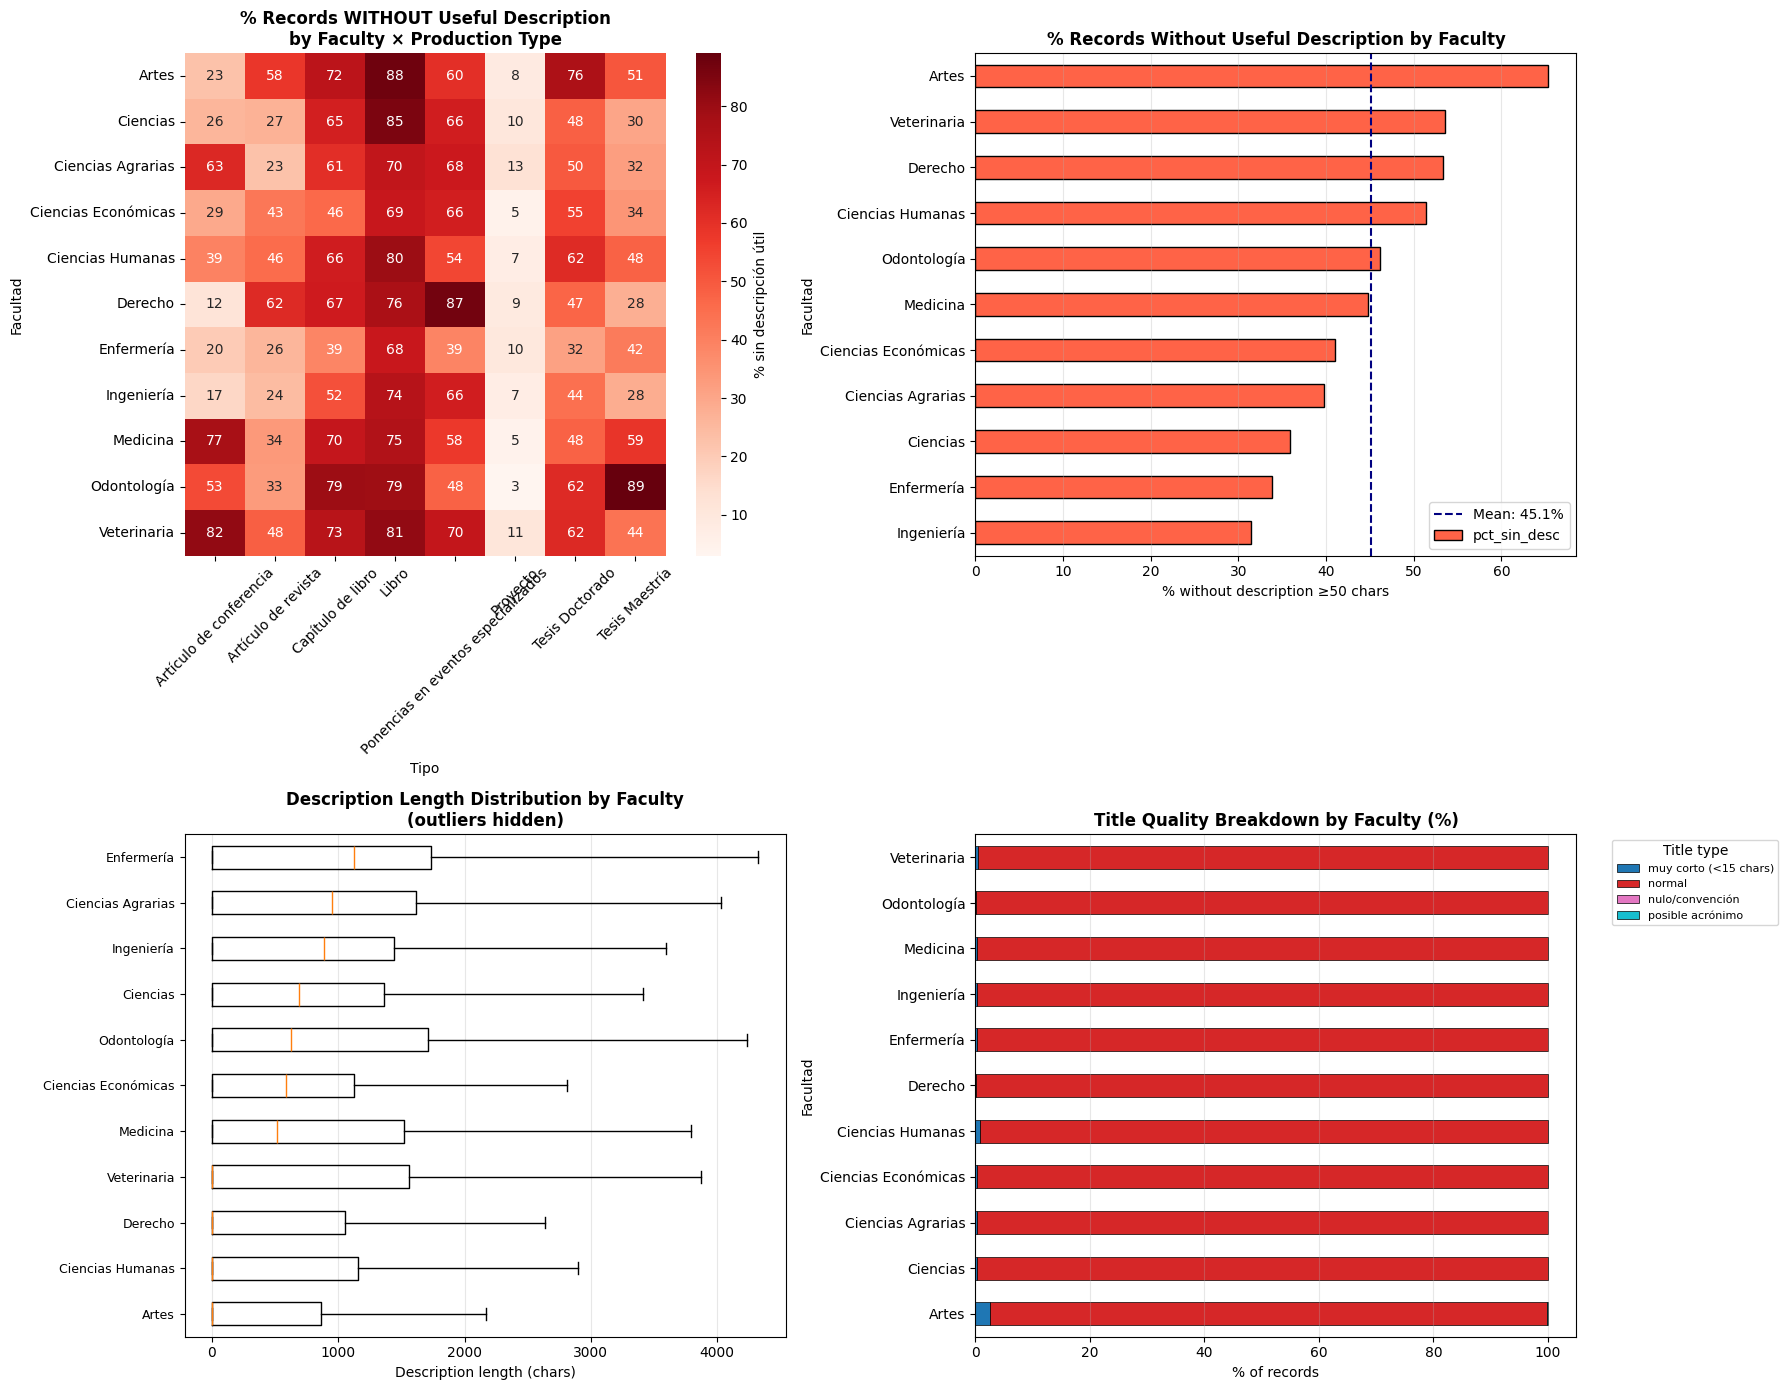


5. Estimated NLP utility by Faculty (records WITH description ≥50 chars):


,total,con_desc_util,pct_sin_desc,pct_util
Facultad,,,,
Artes,6859,2383,65.3,34.7
Veterinaria,2947,1366,53.6,46.4
Derecho,4006,1870,53.3,46.7
Ciencias Humanas,9495,4611,51.4,48.6
Odontología,2183,1176,46.1,53.9
Medicina,18794,10379,44.8,55.2
Ciencias Económicas,3354,1979,41.0,59.0
Ciencias Agrarias,4147,2497,39.8,60.2
Ciencias,31768,20362,35.9,64.1



⚠️  Faculties with >60% missing descriptions may be problematic for topic modeling.
   Candidate faculties to consider excluding or flagging: ['Artes']


In [16]:
print("=" * 60)
print("MISSING / SHORT CONTENT ANALYSIS BY FACULTY AND TYPE")
print("=" * 60)

# Build a richness profile per record
productos_bogota['_tiene_desc'] = (
    productos_bogota['Descripción original'].notna() &
    ~productos_bogota['Descripción original'].apply(es_valor_nulo_convencion) &
    (productos_bogota['Descripción original'].fillna('').str.strip().str.len() >= 50)
)
productos_bogota['_tiene_titulo_largo'] = (
    productos_bogota['Título original'].fillna('').str.strip().str.len() >= 15
)
productos_bogota['_titulo_tipo'] = productos_bogota['Título original'].apply(clasificar_titulo)

# --- 1. Missing descriptions by Faculty ---
print("\n1. Missing/short descriptions by Faculty:")
desc_por_facultad = productos_bogota.groupby('Facultad').agg(
    total=('_tiene_desc', 'count'),
    con_desc_util=('_tiene_desc', 'sum'),
).assign(
    sin_desc=lambda df: df['total'] - df['con_desc_util'],
    pct_sin_desc=lambda df: (df['sin_desc'] / df['total'] * 100).round(1)
).sort_values('pct_sin_desc', ascending=False)
display(desc_por_facultad)

# --- 2. Missing descriptions by Tipo ---
print("\n2. Missing/short descriptions by Tipo:")
desc_por_tipo = productos_bogota.groupby('Tipo').agg(
    total=('_tiene_desc', 'count'),
    con_desc_util=('_tiene_desc', 'sum'),
).assign(
    sin_desc=lambda df: df['total'] - df['con_desc_util'],
    pct_sin_desc=lambda df: (df['sin_desc'] / df['total'] * 100).round(1)
).sort_values('pct_sin_desc', ascending=False)
display(desc_por_tipo)

# --- 3. Average description length by Faculty ---
productos_bogota['_desc_len_real'] = (
    productos_bogota['Descripción original']
    .apply(lambda x: len(str(x).strip()) if pd.notna(x) and not es_valor_nulo_convencion(x) else 0)
)
print("\n3. Average description length by Faculty:")
display(
    productos_bogota.groupby('Facultad')['_desc_len_real']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_desc_len', 'median': 'med_desc_len', 'count': 'n_records'})
    .sort_values('avg_desc_len')
    .round(1)
)

# --- 4. Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Heatmap: % missing description by Faculty x Tipo (top 8 tipos)
top_tipos = productos_bogota['Tipo'].value_counts().head(8).index
pivot_missing = productos_bogota[productos_bogota['Tipo'].isin(top_tipos)].pivot_table(
    index='Facultad', columns='Tipo',
    values='_tiene_desc', aggfunc=lambda x: (1 - x.mean()) * 100
).round(1)
sns.heatmap(pivot_missing, annot=True, fmt='.0f', cmap='Reds',
            ax=axes[0, 0], cbar_kws={'label': '% sin descripción útil'})
axes[0, 0].set_title('% Records WITHOUT Useful Description\nby Faculty × Production Type', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Bar: % missing by faculty
desc_por_facultad['pct_sin_desc'].sort_values().plot(
    kind='barh', ax=axes[0, 1], color='tomato', edgecolor='black')
axes[0, 1].set_title('% Records Without Useful Description by Faculty', fontweight='bold')
axes[0, 1].set_xlabel('% without description ≥50 chars')
axes[0, 1].axvline(x=desc_por_facultad['pct_sin_desc'].mean(), color='navy',
                    linestyle='--', label=f"Mean: {desc_por_facultad['pct_sin_desc'].mean():.1f}%")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Boxplot: description length by Faculty
facultades_orden = (
    productos_bogota.groupby('Facultad')['_desc_len_real']
    .median().sort_values().index
)
datos_box = [
    productos_bogota[productos_bogota['Facultad'] == f]['_desc_len_real'].values
    for f in facultades_orden
]
axes[1, 0].boxplot(datos_box, labels=facultades_orden, vert=False, showfliers=False)
axes[1, 0].set_title('Description Length Distribution by Faculty\n(outliers hidden)', fontweight='bold')
axes[1, 0].set_xlabel('Description length (chars)')
axes[1, 0].tick_params(axis='y', labelsize=9)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Stacked bar: title type breakdown by faculty
titulo_tipo_pivot = productos_bogota.pivot_table(
    index='Facultad', columns='_titulo_tipo', aggfunc='size', fill_value=0
)
titulo_tipo_pct = titulo_tipo_pivot.div(titulo_tipo_pivot.sum(axis=1), axis=0) * 100
titulo_tipo_pct.plot(kind='barh', stacked=True, ax=axes[1, 1],
                      colormap='tab10', edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Title Quality Breakdown by Faculty (%)', fontweight='bold')
axes[1, 1].set_xlabel('% of records')
axes[1, 1].legend(title='Title type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# --- 5. NLP utility score ---
print("\n5. Estimated NLP utility by Faculty (records WITH description ≥50 chars):")
utilidad = desc_por_facultad[['total', 'con_desc_util', 'pct_sin_desc']].copy()
utilidad['pct_util'] = (100 - utilidad['pct_sin_desc']).round(1)
display(utilidad.sort_values('pct_util'))

print("\n⚠️  Faculties with >60% missing descriptions may be problematic for topic modeling.")
problematicas = utilidad[utilidad['pct_sin_desc'] > 60].index.tolist()
if problematicas:
    print(f"   Candidate faculties to consider excluding or flagging: {problematicas}")
else:
    print("   No faculty exceeds 60% missing descriptions threshold.")

# Cleanup helper columns
productos_bogota.drop(columns=['_tiene_desc', '_tiene_titulo_largo', '_titulo_tipo',
                                '_desc_len_real'], inplace=True, errors='ignore')

### 2.1.7. Missing Value Treatment

In [17]:
print("=" * 60)
print("MISSING VALUE TREATMENT")
print("=" * 60)

def es_texto_util(val, min_chars=10):
    """Returns True if the value is a non-null, non-convention string with enough content."""
    if es_valor_nulo_convencion(val):
        return False
    return len(str(val).strip()) >= min_chars

# --- Audit before treatment ---
sin_titulo = ~productos_bogota['Título original'].apply(es_texto_util)
sin_desc = ~productos_bogota['Descripción original'].apply(lambda x: es_texto_util(x, min_chars=50))

print(f"Records without usable title: {sin_titulo.sum()}")
print(f"Records without usable description (≥50 chars): {sin_desc.sum()}")
print(f"Records with neither: {(sin_titulo & sin_desc).sum()}")

# --- Strategy ---
# 1. Normalize convention nulls to real NaN
for col in ['Título original', 'Descripción original', 'Idioma']:
    mask_conv = productos_bogota[col].apply(
        lambda x: not pd.isna(x) and str(x).strip().lower() in CONVENCIONES_NULAS_ESTATICAS
    )
    productos_bogota.loc[mask_conv, col] = np.nan
    print(f"  '{col}': {mask_conv.sum()} convention nulls → NaN")

# 2. Records with no title AND no description → drop (nothing usable for modeling)
mask_drop = (
    productos_bogota['Título original'].isna() &
    productos_bogota['Descripción original'].isna()
)
print(f"\nDropping {mask_drop.sum()} records with no title and no description.")
productos_bogota = productos_bogota[~mask_drop].reset_index(drop=True)

# 3. Create combined text column (title + description) — used in both pipelines
def combinar_titulo_descripcion(row):
    titulo = str(row['Título original']).strip() if pd.notna(row['Título original']) else ''
    desc = str(row['Descripción original']).strip() if pd.notna(row['Descripción original']) else ''
    if titulo and desc:
        return f"{titulo}. {desc}"
    return titulo or desc

productos_bogota['texto_combinado'] = productos_bogota.apply(combinar_titulo_descripcion, axis=1)

print(f"\nRecords remaining: {len(productos_bogota)}")
print(f"Records using title-only (no description): {productos_bogota['Descripción original'].isna().sum()}")
print(f"Combined text column created: 'texto_combinado'")
print(f"Sample:\n{productos_bogota['texto_combinado'].iloc[0][:300]}")

MISSING VALUE TREATMENT
Records without usable title: 207
Records without usable description (≥50 chars): 42424
Records with neither: 94
  'Título original': 0 convention nulls → NaN
  'Descripción original': 0 convention nulls → NaN
  'Idioma': 0 convention nulls → NaN

Dropping 5 records with no title and no description.

Records remaining: 100842
Records using title-only (no description): 42291
Combined text column created: 'texto_combinado'
Sample:
Consistency and stability are considered scientific properties of school effect. These properties are important in determining if school effect is constant along subjects and are perdurable during the time. The purpose of this research is to estimate continuity and stability in Colombian high school


### 2.1.8. Language Detection

In [18]:
print("=" * 60)
print("LANGUAGE DETECTION (Lingua)")
print("=" * 60)

try:
    HAS_LINGUA = True
    print("lingua-language-detector available.")
except ImportError:
    HAS_LINGUA = False
    print("⚠️  lingua not installed. Run: pip install lingua-language-detector")
    print("   Falling back to langdetect.")

# --- Build Lingua detector ---
LINGUA_LANGUAGES = [
    Language.SPANISH, Language.ENGLISH, Language.FRENCH,
    Language.PORTUGUESE, Language.GERMAN, Language.ITALIAN,
    Language.CATALAN,
]

LANG_CODE_MAP = {
    'SPANISH': 'Español', 'ENGLISH': 'Inglés', 'FRENCH': 'Francés',
    'PORTUGUESE': 'Portugués', 'GERMAN': 'Alemán', 'ITALIAN': 'Italiano',
    'CATALAN': 'Catalán', 'GALICIAN': 'Gallego',
}

if HAS_LINGUA:
    detector = (
        LanguageDetectorBuilder
        .from_languages(*LINGUA_LANGUAGES)
        .with_minimum_relative_distance(0.15)  # confidence threshold
        .build()
    )

def detectar_idioma_lingua(titulo, descripcion, min_chars=20):
    """
    Detect language using Lingua.
    Strategy: use description if long enough, otherwise combine title + description.
    This avoids the case where an English title masks a Spanish description.
    """
    desc_str = str(descripcion).strip() if pd.notna(descripcion) and not es_valor_nulo_convencion(descripcion) else ''
    titulo_str = str(titulo).strip() if pd.notna(titulo) and not es_valor_nulo_convencion(titulo) else ''

    # Prefer description (longer, more representative)
    # Use combined only if description is very short
    if len(desc_str) >= 20:
        texto_deteccion = desc_str
    elif len(desc_str) >= min_chars:
        texto_deteccion = f"{titulo_str} {desc_str}".strip()
    elif len(titulo_str) >= min_chars:
        texto_deteccion = titulo_str
    else:
        return 'Desconocido'

    result = detector.detect_language_of(texto_deteccion)

    if result is None:
        return 'Desconocido'

    lang_name = result.name  # e.g. 'SPANISH'
    return LANG_CODE_MAP.get(lang_name, f'Otro ({lang_name.title()})')

# --- Only detect where Idioma is missing ---
mask_sin_idioma = productos_bogota['Idioma'].isna()
print(f"Records missing language label: {mask_sin_idioma.sum()}")
print("Running language detection (this may take a moment)...")

productos_bogota.loc[mask_sin_idioma, 'Idioma'] = [
    detectar_idioma_lingua(titulo, descripcion)
    for titulo, descripcion in zip(
        productos_bogota.loc[mask_sin_idioma, 'Título original'], 
        productos_bogota.loc[mask_sin_idioma, 'Descripción original']
    )
]

# --- Also re-detect where the existing label might be based on title only ---
# (This corrects cases where a Spanish abstract was labeled 'Inglés' due to English title)
print("\nRe-checking records labeled as 'Inglés' that have a Spanish description...")
mask_ingles = productos_bogota['Idioma'] == 'Inglés'
mask_desc_larga = productos_bogota['Descripción original'].fillna('').str.len() >= 20

sospechosos = mask_ingles & mask_desc_larga
print(f"  Candidates (English label + long description): {sospechosos.sum()}")

confirmaciones = []
descripciones_sospechosas = productos_bogota.loc[sospechosos, 'Descripción original']
for idx, desc in descripciones_sospechosas.items():
    idioma_desc = detectar_idioma_lingua('', desc)
    if idioma_desc not in ('Inglés', 'Desconocido'):
        confirmaciones.append((idx, 'Inglés', idioma_desc))

print(f"  Records where description language differs from title: {len(confirmaciones)}")
if confirmaciones:
    print("  Sample corrections:")
    for idx, antes, despues in confirmaciones[:10]:
        titulo = productos_bogota.at[idx, 'Título original']
        print(f"    [{idx}] '{titulo[:60]}...' → {antes} → {despues}")

    # Apply corrections efficiently
    for idx, _, nuevo_idioma in confirmaciones:
        productos_bogota.at[idx, 'Idioma'] = nuevo_idioma
    print(f"  Applied {len(confirmaciones)} language corrections.")

print("\nFinal language distribution:")
display(
    productos_bogota['Idioma'].value_counts(dropna=False)
    .to_frame("count")
    .assign(pct=lambda df: (df['count'] / len(productos_bogota) * 100).round(2))
)

LANGUAGE DETECTION (Lingua)
lingua-language-detector available.
Records missing language label: 7100
Running language detection (this may take a moment)...

Re-checking records labeled as 'Inglés' that have a Spanish description...
  Candidates (English label + long description): 28147
  Records where description language differs from title: 270
  Sample corrections:
    [169] '20 years' journey of the profile journal in ELT research...' → Inglés → Español
    [738] 'A facile approach toward 8-o-4'-neolignans: synthesis of thr...' → Inglés → Español
    [1029] 'A model for addressing the chronic disease care burden in Co...' → Inglés → Español
    [1107] 'A multiscale for mulation for FEM and IgA...' → Inglés → Español
    [1163] 'A new genus and two new species of Apomecynini, a new specie...' → Inglés → Español
    [1225] 'A New Species of Eranina Monné, 2005 (Coleoptera: Cerambycid...' → Inglés → Español
    [1331] 'A note on zip and reversible skew pbw extensions...' → Inglés → Esp

,count,pct
Idioma,,
Español,58681,58.19
Inglés,36400,36.10
Desconocido,1226,1.22
Portugués,1167,1.16
Galicia,914,0.91
Italiano,507,0.50
Alemán,481,0.48
Francés,471,0.47
Indonesio,411,0.41


In [19]:
# After language detection — cross-check with faculty
print("Language × Faculty cross-table (sanity check):")
lang_fac = pd.crosstab(
    productos_bogota['Facultad'],
    productos_bogota['Idioma'],
    normalize='index'
).round(3) * 100

display(lang_fac)

print("\n⚠️  Faculties where English > 70% of publications (flag for review):")
if 'Inglés' in lang_fac.columns:
    display(lang_fac[lang_fac['Inglés'] > 70][['Inglés']])

Language × Faculty cross-table (sanity check):


Idioma,Africanos,Alemán,Catalán,Checo,Danés,Desconocido,Eslovaca,Esloveno,Español,Estonia,...,Latin,Letonia,Lituano,Noruego,Portugués,Rumania,Ruso,Sueco,Turco,Vasco
Facultad,,,,,,,,,,,,,,,,,,,,,
Artes,0.0,0.5,0.5,0.0,0.0,4.6,0.0,0.1,76.7,0.0,...,0.0,0.0,0.4,0.0,4.3,0.3,0.0,0.0,0.0,0.2
Ciencias,0.0,0.3,0.1,0.0,0.0,1.0,0.0,0.0,46.3,0.0,...,0.0,0.0,0.1,0.0,0.7,0.2,0.0,0.0,0.0,0.0
Ciencias Agrarias,0.0,0.6,0.1,0.0,0.0,0.5,0.0,0.0,61.9,0.0,...,0.0,0.0,0.0,0.0,0.9,0.0,0.0,0.0,0.0,0.0
Ciencias Económicas,0.0,0.1,0.1,0.0,0.0,1.0,0.0,0.0,62.8,0.0,...,0.0,0.0,0.0,0.0,0.5,0.1,0.0,0.0,0.0,0.1
Ciencias Humanas,0.0,0.4,0.1,0.0,0.0,1.4,0.0,0.0,75.5,0.0,...,0.0,0.0,0.1,0.0,1.8,0.2,0.0,0.0,0.0,0.1
Derecho,0.0,1.0,0.3,0.0,0.0,0.8,0.0,0.0,87.5,0.0,...,0.0,0.0,0.2,0.0,0.8,0.2,0.0,0.0,0.0,0.1
Enfermería,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.0,73.3,0.0,...,0.0,0.0,0.0,0.0,1.2,0.0,0.0,0.0,0.0,0.0
Ingeniería,0.0,0.9,0.0,0.0,0.0,0.5,0.0,0.0,51.0,0.0,...,0.0,0.0,0.1,0.0,0.6,0.0,0.0,0.0,0.0,0.0
Medicina,0.0,0.5,0.3,0.0,0.0,1.1,0.0,0.0,57.8,0.0,...,0.0,0.0,0.2,0.0,1.1,0.2,0.0,0.0,0.0,0.1



⚠️  Faculties where English > 70% of publications (flag for review):


Idioma,Inglés
Facultad,


### 2.1.9. Embeddings Pipeline — Final Summary

In [20]:
# Summary of the embeddings-ready column
print("=" * 60)
print("EMBEDDINGS PIPELINE — FINAL TEXT SUMMARY")
print("=" * 60)

productos_bogota['texto_embeddings'] = productos_bogota['texto_combinado']

resumen_emb = pd.DataFrame({
    'total_records': [len(productos_bogota)],
    'usable_texts': [(productos_bogota['texto_embeddings'].str.strip() != '').sum()],
    'mean_length_chars': [productos_bogota['texto_embeddings'].str.len().mean().round(0)],
    'median_length_chars': [productos_bogota['texto_embeddings'].str.len().median()],
})
display(resumen_emb)

print("\nSample (texto_embeddings):")
for i in range(3):
    print(f"\n[{i}] {productos_bogota['texto_embeddings'].iloc[i][:300]}")
    print("-" * 60)

EMBEDDINGS PIPELINE — FINAL TEXT SUMMARY


,total_records,usable_texts,mean_length_chars,median_length_chars
0,100842,100842,953.0,690.0



Sample (texto_embeddings):

[0] Consistency and stability are considered scientific properties of school effect. These properties are important in determining if school effect is constant along subjects and are perdurable during the time. The purpose of this research is to estimate continuity and stability in Colombian high school
------------------------------------------------------------

[1] {0,1}-brauer configuration algebras and their applications in graph energy theory. The energy E(G) of a graph G is the sum of the absolute values of its adjacency matrix. In contrast, the trace norm of a digraph Q, which is the sum of the singular values of the corresponding adjacency matrix, is the
------------------------------------------------------------

[2] (1, 1)-q-coherent pairs. In this paper, we introduce the concept of (1, 1)-q-coherent pair of linear functionals (U,V) as the q-analogue to the generalized coherent pair studied by Delgado and Marcellán in (Methods Appl Anal 11(2):27

## 2.2. Preprocessing for classical NLP (LDA / TF-IDF Pipeline)

### 2.2.1. Load spaCy Models


In [21]:
try:
    nlp_es = spacy.load('es_core_news_md', disable=['parser', 'ner'])
    print("Spanish spaCy model loaded.")
except OSError:
    nlp_es = None
    print("⚠️ Spanish spaCy model not found. Run: python -m spacy download es_core_news_md")

try:
    nlp_en = spacy.load('en_core_web_md', disable=['parser', 'ner'])
    print("English spaCy model loaded.")
except OSError:
    nlp_en = None
    print("⚠️ English spaCy model not found. Run: python -m spacy download en_core_web_md")

Spanish spaCy model loaded.
English spaCy model loaded.


### 2.2.2. Stopwords lists

In [22]:
# Combine NLTK stopwords for Spanish and English
stop_es = set(stopwords.words('spanish'))
stop_en = set(stopwords.words('english'))

# Domain-specific stopwords (academic boilerplate)
stop_dominio = {
    'estudio', 'trabajo', 'artículo', 'paper', 'article', 'research',
    'resultado', 'resultados', 'results', 'method', 'methods', 'método', 'métodos',
    'análisis', 'analysis', 'caso', 'casos', 'case', 'objetivo', 'objectives',
    'conclusión', 'conclusiones', 'conclusion', 'conclusions',
    'propuesta', 'propuesto', 'proposed', 'approach', 'study', 'show', 'shown',
    'present', 'presenta', 'presentamos', 'identified', 'identificado',
    'también', 'además', 'however', 'furthermore', 'thus', 'therefore'
}

STOPWORDS_COMBINADAS = stop_es | stop_en | stop_dominio
print(f"Total stopwords: {len(STOPWORDS_COMBINADAS)}")

Total stopwords: 545


### 2.2.3. Core Classical Text Pipeline

In [23]:
# 1. PRECOMPILE REGEX (Done once in memory)
PUNCT_PATTERN = re.compile(r'[^\w\s-]')
NUM_PATTERN = re.compile(r'\b\d+\b')
SPACE_PATTERN = re.compile(r'\s+')

def pre_limpieza_regex(texto):
    """Quick string cleaning before passing to spaCy."""
    if pd.isna(texto) or str(texto).strip() == '':
        return ""
    texto = str(texto).lower()
    texto = PUNCT_PATTERN.sub(' ', texto)
    texto = NUM_PATTERN.sub(' ', texto)
    texto = SPACE_PATTERN.sub(' ', texto)
    return texto.strip()

print("1. Applying preliminary Regex cleaning...")
tqdm.pandas(desc="Regex pre-cleaning")
productos_bogota['texto_limpio'] = productos_bogota['texto_combinado'].progress_apply(pre_limpieza_regex)

# 2. SPLIT BY LANGUAGE FOR BATCH PROCESSING
# Assume Spanish by default if not labeled as English
mask_en = productos_bogota['Idioma'].astype(str).str.lower().str.contains('inglés', na=False)
mask_es = ~mask_en

def extraer_tokens_spacy(textos_iterable, modelo_nlp, min_token_len=3):
    """Generator that processes texts in batch using nlp.pipe"""
    # n_process=-1 uses all cores (seems to not be working on local jupyter notebook). batch_size can be tuned (500-1000 is ideal)
    docs = modelo_nlp.pipe(textos_iterable, batch_size=500, n_process=1)
    
    lista_tokens = []
    for doc in tqdm(docs, total=len(textos_iterable), desc="spaCy Pipe processing"):
        tokens = [
            token.lemma_.strip()  # Already lowercased by preliminary cleaning
            for token in doc
            if not token.is_stop
            and not token.is_space
            and token.is_alpha
            and len(token.lemma_) >= min_token_len
            and token.lemma_ not in STOPWORDS_COMBINADAS
        ]
        lista_tokens.append(tokens)
    return lista_tokens

print("\n2. Processing batch in Spanish...")
if nlp_es:
    textos_es = productos_bogota.loc[mask_es, 'texto_limpio'].tolist()
    tokens_es = extraer_tokens_spacy(textos_es, nlp_es)
    # Assign back using the original index
    productos_bogota.loc[mask_es, 'tokens'] = pd.Series(tokens_es, index=productos_bogota[mask_es].index)

print("\n3. Processing batch in English...")
if nlp_en:
    textos_en = productos_bogota.loc[mask_en, 'texto_limpio'].tolist()
    tokens_en = extraer_tokens_spacy(textos_en, nlp_en)
    productos_bogota.loc[mask_en, 'tokens'] = pd.Series(tokens_en, index=productos_bogota[mask_en].index)

# (Optional) If a model failed to load, apply a basic fallback:
failures = productos_bogota['tokens'].isna()
if failures.any():
    print(f"\n⚠️ Applying basic fallback to {failures.sum()} records...")
    productos_bogota.loc[failures, 'tokens'] = productos_bogota.loc[failures, 'texto_limpio'].apply(
        lambda x: [t for t in x.split() if t.isalpha() and len(t) >= 3 and t not in STOPWORDS_COMBINADAS]
    )

productos_bogota['texto_clasico'] = productos_bogota['tokens'].apply(lambda t: ' '.join(t))
print("Tokenization and lemmatization completed")

1. Applying preliminary Regex cleaning...


Regex pre-cleaning: 100%|██████████| 100842/100842 [00:09<00:00, 10717.87it/s]



2. Processing batch in Spanish...


spaCy Pipe processing: 100%|██████████| 64442/64442 [10:46<00:00, 99.71it/s] 



3. Processing batch in English...


spaCy Pipe processing: 100%|██████████| 36400/36400 [08:18<00:00, 73.07it/s] 


Tokenization and lemmatization completed


### 2.2.4. N-Gram Extraction and Build Per-Document N-Gram Tokens

In [24]:
print("=" * 60)
print("N-GRAM EXTRACTION (Gensim Phrases)")
print("=" * 60)

# 1. Prepare the corpus (list of token lists)
# Unlike NLTK, Gensim expects a list of documents (each document = list of tokens).
oraciones = productos_bogota['tokens'].tolist()

print("Training bigram model...")
# min_count: ignore tokens that appear fewer than 10 times in the corpus
# threshold: minimum score to consider two words as a bigram (higher = more strict)
modelo_bigramas = Phrases(oraciones, min_count=10, threshold=10.0)

# Phraser is a memory-efficient wrapper
bigrama_phraser = Phraser(modelo_bigramas)

print("Training trigram model on top of bigrams...")
# For trigrams, pass the corpus already transformed with bigrams
# This detects sequences like 'support_vital' + 'advanced' -> 'support_vital_advanced'
modelo_trigramas = Phrases(bigrama_phraser[oraciones], min_count=5, threshold=10.0)
trigrama_phraser = Phraser(modelo_trigramas)

# 2. Apply the models to the DataFrame
print("Applying n-grams to the dataset...")
tqdm.pandas(desc="Generating n-grams")

def aplicar_ngramas(tokens):
    """Apply bigram and trigram rules to a list of tokens."""
    if not tokens:
        return []
    # Pass through bigram phraser then trigram phraser
    return trigrama_phraser[bigrama_phraser[tokens]]

productos_bogota['tokens_ngrams'] = productos_bogota['tokens'].progress_apply(aplicar_ngramas)

# 3. Create the final string for TF-IDF
productos_bogota['texto_clasico_ngrams'] = productos_bogota['tokens_ngrams'].apply(lambda t: ' '.join(t))

todos_tokens = [token for lista_tokens in productos_bogota['tokens_ngrams'] for token in lista_tokens]

print("Column 'tokens_ngrams' and 'texto_clasico_ngrams' created successfully")
print(f"Sample (record 0): {productos_bogota['tokens_ngrams'].iloc[0][:20]}")

N-GRAM EXTRACTION (Gensim Phrases)
Training bigram model...
Training trigram model on top of bigrams...
Applying n-grams to the dataset...


Generating n-grams: 100%|██████████| 100842/100842 [00:12<00:00, 8060.60it/s]


Column 'tokens_ngrams' and 'texto_clasico_ngrams' created successfully
Sample (record 0): ['consistency', 'stability', 'consider', 'scientific', 'property', 'school', 'effect', 'property', 'important', 'determine', 'school', 'effect', 'constant', 'subject', 'perdurable', 'time', 'purpose', 'estimate', 'continuity', 'stability']


# 3. Visualization: Classical vs Embeddings Pipeline Comparison

VISUALIZATION — PIPELINE COMPARISON


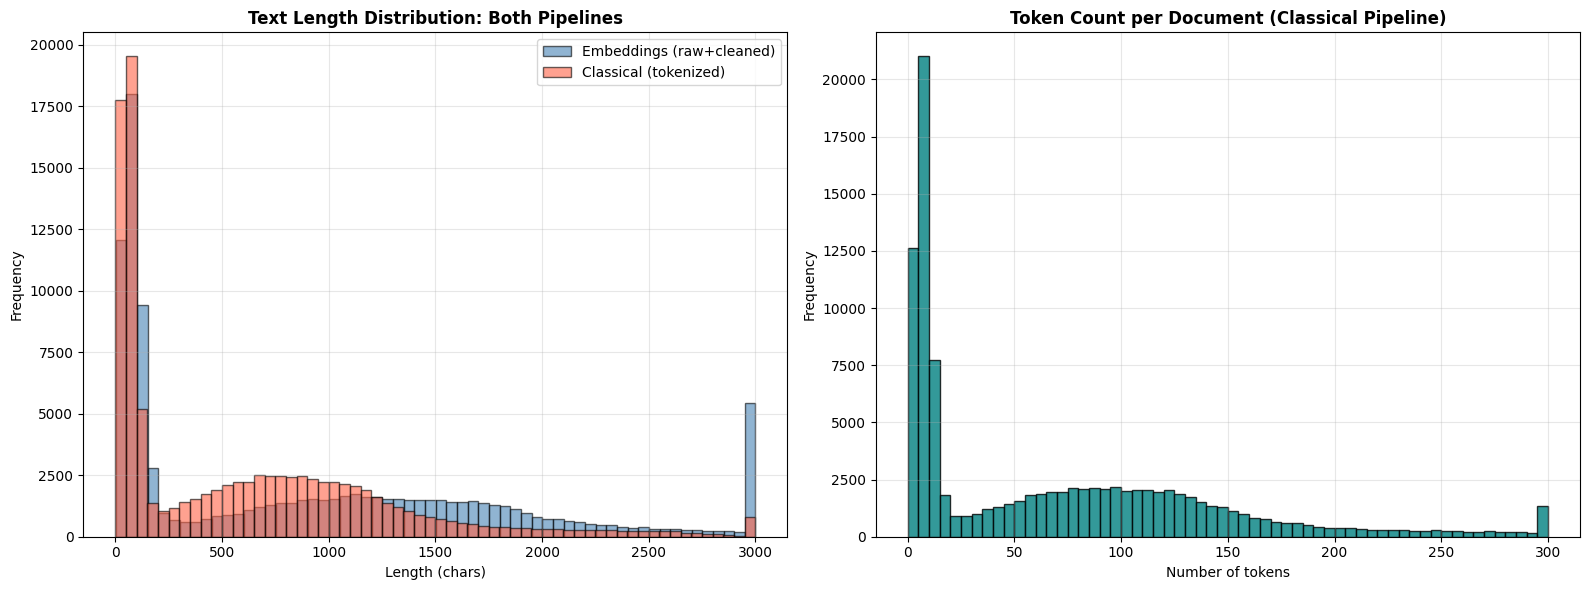

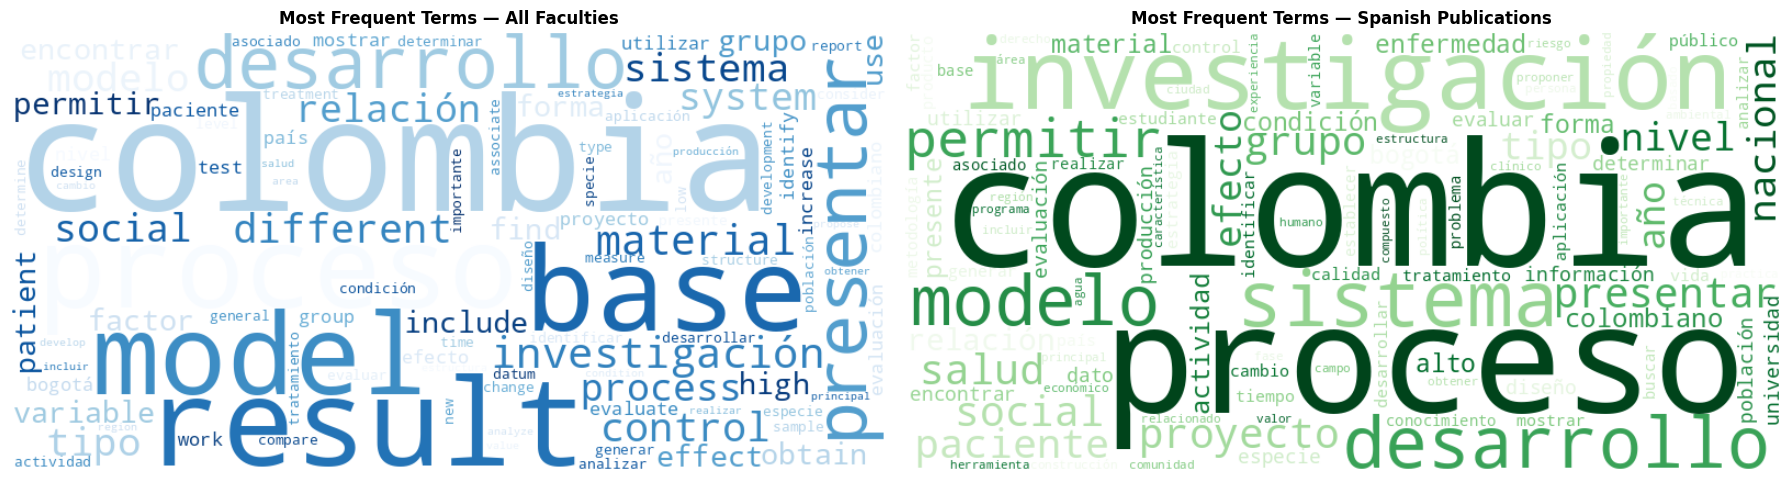

In [25]:
print("=" * 60)
print("VISUALIZATION — PIPELINE COMPARISON")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Text length: raw combined vs classical processed ---
len_raw = productos_bogota['texto_embeddings'].str.len()
len_clasico = productos_bogota['texto_clasico'].str.len()

axes[0].hist(len_raw.clip(upper=3000), bins=60, alpha=0.6, label='Embeddings (raw+cleaned)', color='steelblue', edgecolor='black')
axes[0].hist(len_clasico.clip(upper=3000), bins=60, alpha=0.6, label='Classical (tokenized)', color='tomato', edgecolor='black')
axes[0].set_title('Text Length Distribution: Both Pipelines', fontweight='bold')
axes[0].set_xlabel('Length (chars)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Token count per document ---
n_tokens = productos_bogota['tokens'].apply(len)
axes[1].hist(n_tokens.clip(upper=300), bins=60, color='teal', edgecolor='black', alpha=0.8)
axes[1].set_title('Token Count per Document (Classical Pipeline)', fontweight='bold')
axes[1].set_xlabel('Number of tokens')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Most frequent terms (WordClouds) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

freq_dict = Counter(todos_tokens)

wc_all = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='Blues').generate_from_frequencies(freq_dict)
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].set_title('Most Frequent Terms — All Faculties', fontweight='bold')
axes[0].axis('off')

# Language-specific: Spanish only
tokens_es = [
    t for tokens, idioma in zip(productos_bogota['tokens'], productos_bogota['Idioma'])
    for t in tokens
    if idioma and 'español' in str(idioma).lower()
]
freq_es = Counter(tokens_es)
wc_es = WordCloud(width=800, height=400, background_color='white',
                  max_words=100, colormap='Greens').generate_from_frequencies(freq_es)
axes[1].imshow(wc_es, interpolation='bilinear')
axes[1].set_title('Most Frequent Terms — Spanish Publications', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [26]:
print("=" * 60)
print("POST-PREPROCESSING TEXT QUALITY AUDIT")
print("=" * 60)

problemas = []

# 1. Texts that became empty after classical preprocessing
vacios = productos_bogota['texto_clasico'].str.strip() == ''
problemas.append(('Empty after classical pipeline', vacios.sum()))

# 2. Texts with very few tokens (< 5) — likely not useful for LDA
pocos_tokens = productos_bogota['tokens'].apply(len) < 5
problemas.append(('< 5 tokens (classical pipeline)', pocos_tokens.sum()))

# 3. Embeddings text very short
emb_corto = productos_bogota['texto_embeddings'].str.len() < 30
problemas.append(('Embeddings text < 30 chars', emb_corto.sum()))

# 4. Noisy titles still present
if '_titulo_es_ruido' in productos_bogota.columns:
    problemas.append(('Noisy titles (preface/editorial)', productos_bogota['_titulo_es_ruido'].sum()))

resumen_problemas = pd.DataFrame(problemas, columns=['Issue', 'Count'])
resumen_problemas['% of total'] = (resumen_problemas['Count'] / len(productos_bogota) * 100).round(2)
display(resumen_problemas)

# Flag for downstream filtering
productos_bogota['_util_para_modelado'] = (
    (~vacios) &
    (~pocos_tokens) &
    (~emb_corto) &
    (~productos_bogota.get('_titulo_es_ruido', pd.Series(False, index=productos_bogota.index)))
)
n_util = productos_bogota['_util_para_modelado'].sum()
print(f"\nRecords suitable for topic modeling: {n_util}/{len(productos_bogota)} ({n_util/len(productos_bogota)*100:.1f}%)")
print("Column '_util_para_modelado' added for downstream filtering.")

POST-PREPROCESSING TEXT QUALITY AUDIT


,Issue,Count,% of total
0,Empty after classical pipeline,49,0.05
1,< 5 tokens (classical pipeline),12642,12.54
2,Embeddings text < 30 chars,3884,3.85



Records suitable for topic modeling: 88199/100842 (87.5%)
Column '_util_para_modelado' added for downstream filtering.


# 4. Save Preprocessed Data

In [27]:
print("=" * 60)
print("SAVING PREPROCESSED DATA")
print("=" * 60)

output_path = base_path / "processed"
output_path.mkdir(parents=True, exist_ok=True)

columnas_salida = [
    'Título original', 'Descripción original', 'Coautores', 'Idioma',
    'Tipo', 'Fuente', 'Facultad', 'Fecha', 'Revista / Conferencia',
    'DOI', 'ISBN', 'ISSN',
    'texto_combinado',
    'texto_embeddings',
    'tokens',
    'texto_clasico',
    'tokens_ngrams',
    'texto_clasico_ngrams',
]

columnas_disponibles = [c for c in columnas_salida if c in productos_bogota.columns]

# ── CSV: serialize lists as pipe-separated strings ──────────────────────────
df_output = productos_bogota[columnas_disponibles].copy()
for col in ['tokens', 'tokens_ngrams']:
    if col in df_output.columns:
        df_output[col] = df_output[col].apply(
            lambda x: '|'.join(x) if isinstance(x, list) else (x or '')
        )

df_output.to_csv(output_path / "productos_preprocesados.csv", index=False)
print(f"Saved CSV: {output_path / 'productos_preprocesados.csv'} — {df_output.shape}")

# ── Parquet: convert lists to plain strings BEFORE saving ───────────────────
# PyArrow cannot infer a schema for mixed Python list / None columns.
# Serialise as pipe-separated strings (same convention as CSV).
df_parquet = productos_bogota[columnas_disponibles].copy()
for col in ['tokens', 'tokens_ngrams']:
    if col in df_parquet.columns:
        df_parquet[col] = df_parquet[col].apply(
            lambda x: '|'.join(x) if isinstance(x, list) else (x or '')
        )

df_parquet.to_parquet(
    output_path / "productos_preprocesados.parquet",
    index=False,
    engine='pyarrow',
)
print(f"Saved Parquet: {output_path / 'productos_preprocesados.parquet'}")

# ── Modeling-ready subset ────────────────────────────────────────────────────
_util_mask = productos_bogota.get('_util_para_modelado', pd.Series(True, index=productos_bogota.index))
df_model_ready = df_parquet[_util_mask.values].copy()  # reuse already-serialised df

df_model_ready.to_csv(output_path / "productos_modelado.csv", index=False)
df_model_ready.to_parquet(
    output_path / "productos_modelado.parquet",
    index=False,
    engine='pyarrow',
)
print(f"Modeling-ready subset saved: {len(df_model_ready)} records")

SAVING PREPROCESSED DATA
Saved CSV: ../data/processed/productos_preprocesados.csv — (100842, 17)
Saved Parquet: ../data/processed/productos_preprocesados.parquet
Modeling-ready subset saved: 88199 records
